In [1]:
from pathlib import Path
from typing import Literal
import matplotlib.pyplot as plt
from gridplots import load_dfmdock_stats, plot_all_grids

source_type:Literal['dfmdock','neighborhood'] = 'dfmdock'
if source_type == 'dfmdock':
    #Literal['darren_inference', 'dfmdock_tr_inference', 'dfmdock_inference_trtrained_deterministic']
    samples_source = 'dfmdock_inference_trtrained_deterministic'
    sample_stats, gt_stats, labels, limits = load_dfmdock_stats(samples_source)
# elif source_type == 'neighborhood':
#     #Literal['centerline_shifts', 'transverse_plane']
#     samples_source = 'centerline_shifts'
#     sample_stats, gt_stats, labels, limits = load_neighborhood_stats(samples_source)


missed source: 2SIC/3integrand_diff_50interp
missed source: 1IRA/3integrand_diff_50interp
missed source: 3integrand_diff_50interp


In [ ]:
plot_all_grids(sample_stats,gt_stats,labels,limits,save=True,outdir=Path(f'gridplots/{samples_source}/'))
plt.close('all')

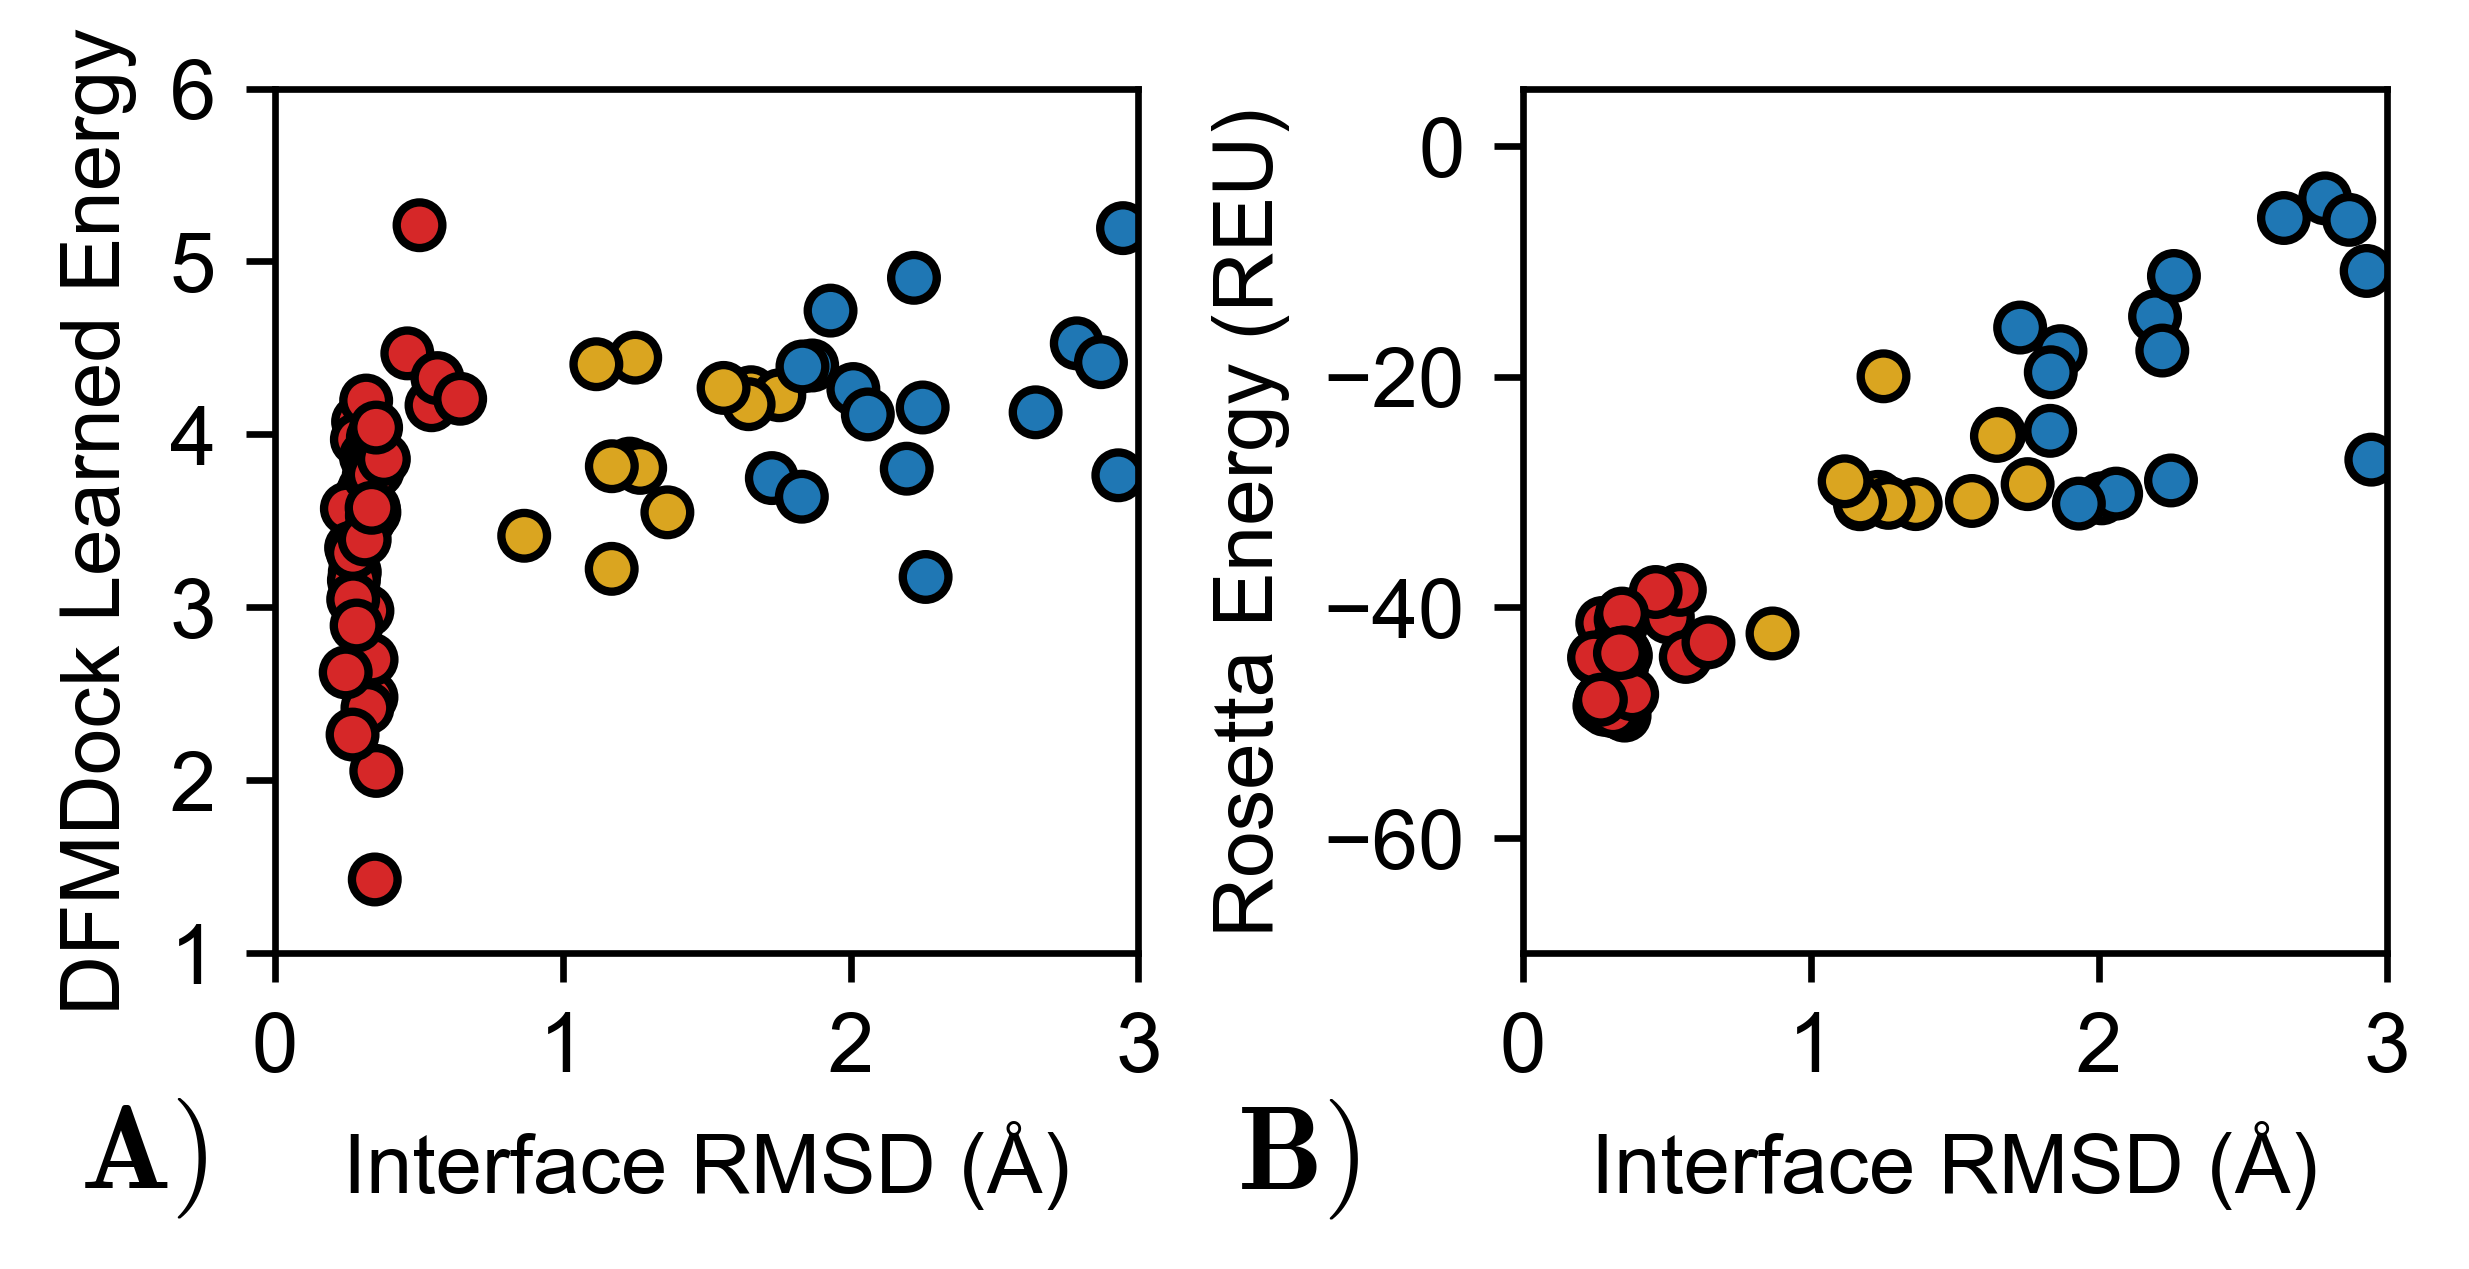

In [ ]:
## GRFP Figure 2

from matplotlib.axes import Axes
from matplotlib.patches import Circle, Rectangle
from matplotlib.transforms import BboxTransformTo, IdentityTransform
from gridplots import plot_samples


xkey = "i_rmsd"
ykey = "flow_nll"
f,(ax1,ax2) = plt.subplots(ncols=2,figsize=(4,2),layout="constrained",dpi=600)

assert isinstance(ax1,Axes) and isinstance(ax2,Axes)

plot_samples(sample_stats,None,'2SIC',xkey,ykey,markersize=30,ax=ax1,
             custom_xlabel="Interface RMSD (Å)",custom_ylabel="DFMDock Learned Energy",
             custom_xlim=(0,3),custom_ylim=(1,6))

ykey = "rosetta_Isc"
plot_samples(sample_stats,None,'2SIC',xkey,ykey,markersize=30,ax=ax2,
             custom_xlabel="Interface RMSD (Å)",custom_ylabel="Rosetta Energy (REU)",
             custom_xlim=(0,3),custom_ylim=limits[ykey])

# f.suptitle("Energy vs Docking Quality")

f.draw(f.canvas.get_renderer())

bbox1 = ax1.get_tightbbox()
trans1 = BboxTransformTo(bbox1)
f.text(0.05,0.05,r'$\bf{A)}$',transform=trans1,fontdict={'fontsize':'x-large'})

bbox2 = ax2.get_tightbbox()
trans2 = BboxTransformTo(bbox2)
f.text(0.05,0.05,r'$\bf{B)}$',transform=trans2,fontdict={'fontsize':'x-large'})

f.savefig("GRFP_Fig2.png",dpi=600,bbox_inches='tight')


New 2SIC Targets: p119, p61 
New 2AYO Targets: p80, p39

##### OUTDATED CODE (NOW IN gridplots.py)

In [1]:
import pickle
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from yaml import load, CLoader as Loader


In [2]:
from matplotlib import font_manager

font_dirs = ['/home/miner/fonts']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Arial'
plt.rcParams["mathtext.fontset"] = 'cm'

In [3]:
parent_folder = Path('../../likelihood_results/likelihoodv3')
def get_likelihood_results(flow_folder, diff_folder,integrand="TotalIntegrand",prior="smax_gaussian"): #makes a dict equivalent to the results dict above but with 'flow_nll' and 'diff_nll' instead of 'flowtime_nll', 'difftime_nll', 'diffspace_nll'
    flow_likelihoods,flow_prior = get_likelihoods(flow_folder,integrand=integrand,prior=prior)
    diff_likelihoods,diff_prior = get_likelihoods(diff_folder,integrand=integrand,prior=prior)
    #TODO: run diff interp?
    
    res = {}

    ids = flow_likelihoods.keys()
    # assert set(ids) == set(orig_results.keys())
    print(set(ids),set(diff_likelihoods.keys()))
    assert set(ids) == set(diff_likelihoods.keys())
    
    
    for id in ids:
        res[id] = rec = {}
        
        n_samples = len(orig_results[id]['rosetta_Isc']) #some of them are missing samples????
        
        rec['flow_nll'] = flow_likelihoods[id][:n_samples]
        rec['diff_nll'] = diff_likelihoods[id][:n_samples]
        rec['flow_prior'] = flow_prior[id][:n_samples]
        rec['diff_prior'] = diff_prior[id][:n_samples]

    return res

def get_gt_results(gt_folder,integrand="TotalIntegrand",prior="smax_gaussian"):
    lfile = parent_folder/gt_folder/"likelihood.csv"
    ldf = pd.read_csv(lfile)

    flowres = dict(zip(ldf['id'],-(ldf[f'integrand:{integrand}']+ldf[f'prior:{prior}'])/3)) #negate because the code is expecting negative log-likelihood; divide by 3 because original code divided by N
    return {'flow_nll':flowres,'rosetta_Isc':orig_gt_results['rosetta_Isc']}
    
def get_likelihoods(likelihood_folder,integrand="TotalIntegrand",prior="smax_gaussian")->dict[str,pd.DataFrame]:
    lfile = likelihood_folder/"likelihood.csv"
    ldf = pd.read_csv(lfile)
    ldf.index = ldf['id'].str.rsplit("/",n=1).str[-1]
    pdb_ids = ldf.index.str.split("_").str[0];

    ldf['pdb_id'] = pdb_ids
    ldf.sort_values(['pdb_id'])

    nlls = {}
    priors = {}
    for id in np.unique(pdb_ids):
        arr = ldf[ldf['pdb_id'] == id]

        #use the index inherent to the series for ordering!
        nlls[id] = -((arr[f'integrand:{integrand}'] + arr[f'prior:{prior}']))/3 #negate because the code is expecting negative log-likelihood; divide by 3 because original code divided by N
        priors[id] = -arr[f'prior:{prior}']/3

    return nlls, priors


In [4]:
def get_dfmdock_inference_stats(dfmdock_stats_csv):
    dfmdock_stats_df = pd.read_csv(dfmdock_stats_csv)
    dfmdock_stats_df.rename(columns={'id':'pdb_id','index':'sample_index','energy':'dfmdock_energy'},inplace=True)
    dfmdock_stats_df.index = dfmdock_stats_df['pdb_id'].astype(str) + '_p' + dfmdock_stats_df['sample_index'].astype(str)
    unique_ids = np.unique(dfmdock_stats_df['pdb_id'])
    results = {}
    for id in unique_ids:
        iddf = dfmdock_stats_df[dfmdock_stats_df['pdb_id'] == id].sort_values('sample_index')
        assert np.all(np.diff(iddf['sample_index']) == 1) #make sure no gaps (paranoia incarnate)
        results[id] = iddf
    return results

In [26]:
from typing import Literal, DefaultDict
samples_source:Literal['darren_inference', 'dfmdock_tr_inference', 'dfmdock_inference_trtrained_deterministic'] = 'dfmdock_inference_trtrained_deterministic'
def copy_keys(dest,source,*keys):
    #convenience function to copy a bunch of key-value pairs from source to dest
    for key in keys:
        dest[key] = source[key]
    

## One big dict which will hold all the stats for the *generated samples*. Start by populating the test metrics generated during sampling:
sample_stats:dict[str,pd.DataFrame] = {}

if samples_source == 'dfmdock_inference_trtrained_deterministic':
    dfmdock_stats_csv = "../../sample_results/dfmdock_inference_trtrained_deterministic/csv_files/db5_test_diffenergy_tr_0_0.5_120_samples_40_steps_dips_.csv"
elif samples_source == 'darren_inference':
    dfmdock_stats_csv = "../../sample_results/darren_sample_results/results/csv_files/db5_test_DFMDock_model_0_0.5_120_samples_40_steps_dips_.csv"
elif samples_source == 'dfmdock_tr_inference':
    dfmdock_stats_csv = "../../sample_results/dfmdock_inference/csv_files/db5_test_DFMDock_model_0_0.5_120_samples_40_steps_dips_.csv"

sample_stats = get_dfmdock_inference_stats(dfmdock_stats_csv)

# Add rosetta energies
if samples_source == 'darren_inference':
    rosetta_csv = "../../dfmdock_perturb_tr_likelihood/refined_scores_darrensamples.csv"
#     with open('../../dfmdock_perturb_tr_likelihood/dfmdock_perturb_tr_likelihood_all.pkl', 'rb') as f:
#         old_results = pickle.load(f)
#     for id in unique_ids:
#         ## very annoying normalization since rosetta misses some
#         rosetta_energy = old_results[id]['rosetta_Isc']
#         sample_stats[id]['rosetta_Isc'] = 
elif samples_source == 'dfmdock_tr_inference':
    raise ValueError()
elif samples_source == 'dfmdock_inference_trtrained_deterministic':
    rosetta_csv = "../../dfmdock_perturb_tr_likelihood/refined_scores_dfmdock_trtrained_deterministic.csv"

rosetta_df = pd.read_csv(rosetta_csv)
for pdb_id in sample_stats:
    iddf = rosetta_df[rosetta_df['pdb_id'] == pdb_id]
    iddf = iddf.sort_values('sample_index')
    
    #Missing Fnat means scoring failed
    iddf = iddf[iddf['Fnat'].notna()]

    #assign values by index. Missing rows will be assigned 'nan', since rosetta doesn't return a value for every structure
    iddf.index = iddf['id']
    sample_stats[pdb_id]['rosetta_Isc'] = iddf['I_sc']



## Same idea as sample_stats, but for the ground truth structures
gt_stats:dict[str,dict[str,float]] = {}
for id in sample_stats:
    gt_stats[id] = {'DockQ': 1, 'c_rmsd': 0, 'i_rmsd': 0, 'l_rmsd': 0, 'fnat': 1, 'num_clashes': 0} #some dummy data

# Use original gt_results' rosetta energy since it's independent of samples and method
with open('../../dfmdock_perturb_tr_likelihood/dfmdock_perturb_tr_likelihood_gt.pkl', 'rb') as f:
    old_gt_results = pickle.load(f)
for id in sample_stats:
    gt_stats[id]['rosetta_Isc'] = old_gt_results['rosetta'][id]



# Dict to hold: 1) the display labels for each inference type, and 2) the axis limits (optional) for each display label
labels:dict[str,str|None] = DefaultDict(lambda: None)
limits:dict[str,tuple[float|None,float|None]|None] = DefaultDict(lambda: None)
labels['DockQ'] = 'DockQ';                             limits['DockQ'] = (-0.05, 1.05)
labels['i_rmsd'] = "Interface RMSD (Å)";               limits['i_rmsd'] = (-0.2,None)
labels['rosetta_Isc'] = "Rosetta Energy (REU)";        limits['rosetta_Isc'] = (-70,5)
labels['dfmdock_energy'] = "DFMDock Predicted Energy"; limits['dfmdock_energy'] = None #TODO: set reasonable limit

### Add Calculated Likelihoods

## New Code
labels.update({"flow_nll": "Learned Energy (Flow)",
             "diff_nll": "Learned Energy (Diffusion)",
             "forwardsde_nll": "Learned Energy (Forward SDE)",
             "diff_10interp_nll": "Learned Energy (Diffusion, Interpolated 10x)",
             "diff_50interp_nll": "Learned Energy (Diffusion, Interpolated 50x)"})
# limits['flow_nll'] = (2,6)

if samples_source == 'darren_inference':
    srcfolder = '../../likelihood_results/likelihoodv3/dfmdock_tr'
elif samples_source == 'dfmdock_tr_inference':
    raise ValueError()
elif samples_source == 'dfmdock_inference_trtrained_deterministic':
    srcfolder = '../../likelihood_results/likelihoodv3/dfmdock_trtrained_deterministic/'
srcfolder = Path(srcfolder)

default_integrand = 'TotalIntegrand'
default_prior = 'smax_gaussian'
def insert_dict(dest,destkey,source):
    for id in source:
        if id in dest:
            dest[id][destkey] = source[id]

#add likelihoods from standard sources where available
sources:dict[str,tuple[str]] = { #where to pull from to fill the keys above
    'flow_nll': ('2SIC/3integrand_flow_40', '1IRA/3integrand_flow_40', '3integrand_flow_40'),
    'diff_nll': ('2SIC/3integrand_diff', '1IRA/3integrand_diff', '3integrand_diff'),
    'diff_10interp_nll': ('2SIC/3integrand_diff_10interp', '1IRA/3integrand_diff_10interp', '3integrand_diff_10interp'),
    'diff_50interp_nll': ('2SIC/3integrand_diff_50interp', '1IRA/3integrand_diff_50interp', '3integrand_diff_50interp'),
    'forwardsde_nll': ('3integrand_forward_sde',),
}
for key,srcs in sources.items():
    for src in srcs:
        try:
            nlls,priors = get_likelihoods(srcfolder/src,integrand=default_integrand,prior=default_prior)
            insert_dict(sample_stats,key,nlls)
        except FileNotFoundError:
            print(f"missed source: {src}")
            pass

#add any misc likelihoods here / override additions from above




## Old Code
labels.update({"flowtime_nll": "Learned Energy (FlowTime)",
             "difftime_nll": "Learned Energy (DiffTime)",
             "diffspace_nll": "Learned Energy (DiffSpace)"})

sources = {'flowtime_nll': "flowtime_dfmdock_perturb_tr.csv",
           'difftime_nll': "difftime_dfmdock_perturb_tr.csv",
           'diffspace_nll': "diffspace_dfmdock_perturb_tr.csv"}

limits['flowtime_nll'] = (-5,10)

if samples_source == 'darren_inference': #TODO: run old code on new samples
    parent_folder = Path("../../dfmdock_perturb_tr_likelihood/likelihood")

elif samples_source == 'dfmdock_inference_trtrained_deterministic':
    parent_folder = Path("../../dfmdock_perturb_tr_likelihood/likelihood_deterministic/")
else:
    raise ValueError()

for key,loc in sources.items():
    likelihood_df = pd.read_csv(parent_folder/loc)
    likelihood_df.index = likelihood_df['id'].str.rsplit('/',n=1).str[-1].str.split(".").str[0].str.split("trajectory_").str[-1] #remove the trajectory prefix if present
    ids = likelihood_df.index.str.split("_").str[0]
    for id in sample_stats:
        iddf = likelihood_df[ids == id]
        sample_stats[id][key] = iddf['nll']

del old_gt_results

In [ ]:
from typing import Literal, Optional
def make_gridplot(sample_results:dict,gt_results:Optional[dict],
                  xtype:str,
                  ytype:str,
                  custom_xlabel:Optional[str]=None, custom_ylabel:Optional[str]=None,
                  custom_xlim:Optional[tuple[float|None,float|None]]=None,custom_ylim:Optional[tuple[float|None,float|None]]=None,
                  #plot_gt = 'if_present' will try to plot ytype (or gt_ytype if specified) from the gt_results dict if the key is present, but will not error if it's not.
                  # plot_gt = True will raise an error if the key is not present in gt_results; plot_gt = False prevents plotting altogether.
                  plot_gt:bool|Literal['if_present']='if_present',gt_ytype:Optional[str]=None, 
                  skip_plot_if_missing:bool=True, #if true, will simply skip individual plots whose x or y value is not present in the sample_results dict. Otherwise, will error.
                  save=False,out_file='gridplots/gridplot.png'):

    
    fig, axes = plt.subplots(5, 5, figsize=(14, 14), sharex=True, sharey=True)
    for i, _id in enumerate(sorted(sample_results.keys())):
        if skip_plot_if_missing and (xtype not in sample_results[_id].columns or ytype not in sample_results[_id].columns): print(f"skipping {_id}"); continue
        ax = axes[i // 5, i % 5]
        #TODO: WHEN DO WE FILTER MORE / LESS?
        idx_to_keep = (sample_results[_id][ytype].notna())
        if 'rosetta_Isc' in sample_results[_id].columns:
            idx_to_keep &= (sample_results[_id]['rosetta_Isc'] > -10000) & (sample_results[_id]['rosetta_Isc'].notna())# & (_results[_id]['flow_nll' if not old_results else 'flowtime_nll'] < 6.4)
            
        # print(xtype,ytype)
        colors = ['gray' if dockq < 0.23 
                  else 'tab:blue' if dockq < 0.49
                  else 'goldenrod' if dockq < 0.80
                  else 'tab:red' for dockq in sample_results[_id]['DockQ'][idx_to_keep]]
        ax.scatter(sample_results[_id][xtype][idx_to_keep], sample_results[_id][ytype][idx_to_keep], s=30, edgecolors='k', linewidths=1, c=colors)

        if gt_results is not None and plot_gt != False:
            yt = gt_ytype or ytype
            if (plot_gt == 'if_present' and xtype in gt_results[_id] and yt in gt_results[_id]) or plot_gt == True:
                ax.scatter(gt_results[_id][xtype], gt_results[_id][gt_ytype or ytype], s=100, c='yellow', marker='*', edgecolors='k', linewidths=1) 
            
        ax.set_title(_id)

        ax.set_xlabel(custom_xlabel or xtype)
        ax.set_ylabel(custom_ylabel or ytype)
        if custom_xlim: ax.set_xlim(*custom_xlim)
        if custom_ylim: ax.set_ylim(*custom_ylim)
        ax.xaxis.set_tick_params(which='both', labelbottom=True)
        ax.yaxis.set_tick_params(which='both', labelbottom=True)
            
    plt.tight_layout()
    fig.set_dpi(300)
    if save:
        out_file = Path(out_file)
        out_file.parent.mkdir(exist_ok=True,parents=True)
        plt.savefig(out_file, dpi=300, bbox_inches='tight')


In [29]:
import itertools
allstats = list(np.unique([k for ks in sample_stats.values() for k in ks.columns]))
allstats.remove('pdb_id'); allstats.remove('sample_index')

ys = [f for f in allstats if f.endswith('nll')] + ['dfmdock_energy','rosetta_Isc']
xs = list(set(allstats).difference(ys)) + ['dfmdock_energy','rosetta_Isc'] #these are interesting both to compare with the nll directly and to act as a proxy for nll when comparing to the other metrics

xs.remove('num_clashes'); xs.remove('c_rmsd'); xs.remove('fnat') #unimportant metrics, take up lots of space in directories

print(f'{xs=}')
print(f'{ys=}')

pairs = list(itertools.product(xs,ys))

pairs.append(('flowtime_nll','flow_nll'))
pairs.append(('flow_nll','diff_nll'))

In [30]:
import itertools
from tqdm import tqdm
for x,y in tqdm(pairs):
    if x == y: continue
    make_gridplot(sample_stats,gt_stats,
                  x,y,
                  custom_xlabel=labels[x],custom_ylabel=labels[y],
                  custom_xlim=limits[x],custom_ylim=limits[y],
                  save=True,out_file=f'gridplots/{samples_source}/{y}_vs_{x}.png')
